# Análisis Exploratorio de Datos (EDA): ACE-III y GDS
---

**Asignatura**: Deep Learning\
**Profesor**: Dr. Juan Bekios\
**Integrantes**:
  - Pablo Cortés
  - Víctor Jopia
  - Kevin Silva

## Introducción
---

El presente notebook realiza un EDA sobre un dataset que contiene las respuestas a una versión reducida del **Addenbrooke's Cognitive Examination III (ACE-III)** y su respectivo diagnóstico con la **Global Deterioration Scale (GDS)**.

El ACE-III es un test de cribado de 15-20 minutos que evalúa cinco dominios cognitivos: atención, memoria, fluidez verbal, lenguaje y habilidades visuoespaciales. Se administra pidiendo al paciente realizar tareas específicas de cada área, como recordar palabras, denominar objetos, dibujar y responder preguntas de orientación.

La GDS es una herramienta clínica de 7 etapas utilizada para evaluar la progresión del deterioro cognitivo y la demencia (especialmente Alzheimer), desde la normalidad (GDS 1) hasta un déficit muy grave (GDS 7). Se enfoca en el estado cognitivo y funcional.

### Estructura del dataset

Cada entrada del conjunto de datos contiene respuestas binarias (acierto/error) a preguntas específicas y múltiples etiquetas, que corresponden a distintas codificaciones del GDS para mitigar el desbalance de clases:

- **Features**: 15 columnas binarias $\{0,1\}$ donde $0$ es una respuesta errónea y $1$ es una respuesta acertada. Algunas columnas por ejemplo son `Día`, `Mes`, `Año`, etc. Típicamente, en el ACE-III se les pregunta a los pacientes por la fecha actual; una respuesta correcta entonces sería marcada con un $1$.

- **Targets**: 6 columnas multiclase que representan una puntuación GDS. La cantidad de clases va a depender del tipo de codificación que tenga la columna. A continuación se muestra una tabla detallando cada codificación:

| Codificación | Agrupación de categorías GDS             | Nº de Clases | Descripción                                               |
|--------------|-------------------------------------------|--------------|-----------------------------------------------------------|
| GDS          | 1, 2, 3, 4, 5, 6–7                        | 6            | Se agrupan solo las categorías más severas (6 y 7)        |
| GDS_1        | 1–3, 4–5, 6–7                             | 3            | Agrupa en leve, moderado y severo                         |
| GDS_2        | 1–2, 3, 4–7                               | 3            | Distingue deterioro leve como clase independiente         |
| GDS_3        | 1–3, 4–7                                  | 2            | Binaria: sin o leve deterioro vs. moderado/severo         |
| GDS_4        | 1, 2–4, 5–7                               | 3            | Mantiene categoría 1 separada                             |
| GDS_5        | 1, 2–3, 4–7                               | 3            | Categoriza deterioro leve como clase intermedia aislada   |

### Objetivos del EDA:

- **Comprensión de los datos**: entender la dimensión del conjunto de datos y ver los tipos de los valores.
  
- **Limpieza de los datos**: encontrar potenciales valores faltantes, valores duplicados y outliers.
  
- **Análisis de distribución**: el problema central de los datos es que las clases de las etiquetas están desbalanceadas, por lo que analizar los distintos tipos de codificaciones GDS permite decidir qué tipo de estrategia se usará para balancear las clases.
  
- **Correlación de las variables**: ver cuáles variables influyen más en la clasificación y así ver si se pueden eliminar variables para reducir la complejidad del modelo y evitar riesgo de sobreajuste.

## Comprensión de los datos
---

### Cargar dataset

In [2]:
import pandas as pd

DATA_PATH = "../data/raw/data.sav"

df = pd.read_spss(DATA_PATH)
df.head()

,ID,Día,Mes,Año,Estación,País,Ciudad,CalleLugar,NumeroPiso,Miguel2,...,Imperial2,A682,Caldera2,Copiapo2,GDS,GDS_R1,GDS_R2,GDS_R3,GDS_R4,GDS_R5
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,2.0,2.0
1,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,4.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,2.0,2.0
4,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,2.0,2.0


### Información básica

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1119 non-null   float64
 1   Día         1119 non-null   float64
 2   Mes         1119 non-null   float64
 3   Año         1119 non-null   float64
 4   Estación    1119 non-null   float64
 5   País        1119 non-null   float64
 6   Ciudad      1119 non-null   float64
 7   CalleLugar  1119 non-null   float64
 8   NumeroPiso  1119 non-null   float64
 9   Miguel2     1119 non-null   float64
 10  González2   1119 non-null   float64
 11  Avenida2    1119 non-null   float64
 12  Imperial2   1119 non-null   float64
 13  A682        1119 non-null   float64
 14  Caldera2    1119 non-null   float64
 15  Copiapo2    1119 non-null   float64
 16  GDS         1119 non-null   float64
 17  GDS_R1      1119 non-null   float64
 18  GDS_R2      1119 non-null   float64
 19  GDS_R3      1119 non-null  

De este único método se puede deducir la siguiente información:
- Hay un total de **22 columnas**.
- El dataset contiene **1119 entradas**.
- No hay valores nulos.
- Todos los datos son de tipo numérico (`float64`).

### Valores únicos

In [4]:
for col in df.drop(columns=["ID"]).columns:
    unique_values = df[col].unique().tolist()
    print(f"{col}: {sorted(unique_values)}")

Día: [0.0, 1.0]
Mes: [0.0, 1.0]
Año: [0.0, 1.0]
Estación: [0.0, 1.0]
País: [0.0, 1.0]
Ciudad: [0.0, 1.0]
CalleLugar: [0.0, 1.0]
NumeroPiso: [0.0, 1.0]
Miguel2: [0.0, 1.0]
González2: [0.0, 1.0]
Avenida2: [0.0, 1.0]
Imperial2: [0.0, 1.0]
A682: [0.0, 1.0]
Caldera2: [0.0, 1.0]
Copiapo2: [0.0, 1.0]
GDS: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
GDS_R1: [1.0, 2.0, 3.0]
GDS_R2: [1.0, 2.0, 3.0]
GDS_R3: [1.0, 3.0]
GDS_R4: [1.0, 2.0, 3.0]
GDS_R5: [1.0, 2.0, 3.0]


Los datos coinciden con lo descrito anteriormente:

- Las primeras 15 columnas son **binarias** (excluyendo el ID): son las respuestas a las preguntas del ACE-III ($1$ correcto, $0$ incorrecto).
- Las últimas 6 columnas son **multiclase**, y los valores únicos corresponden con la tabla vista anteriormente.

## Limpieza de datos
---

Este paso no es necesario ya que se comprobó que:
- No hay valores nulos. 
  
- No hay outliers (los datos únicos corresponden con lo establecido inicialmente).
  
- Técnicamente no pueden haber duplicados (dos pacientes pueden tener las mismas respuestas y diagnóstico).

## Análisis de distribución
---



AttributeError: 'numpy.ndarray' object has no attribute 'get_figure'

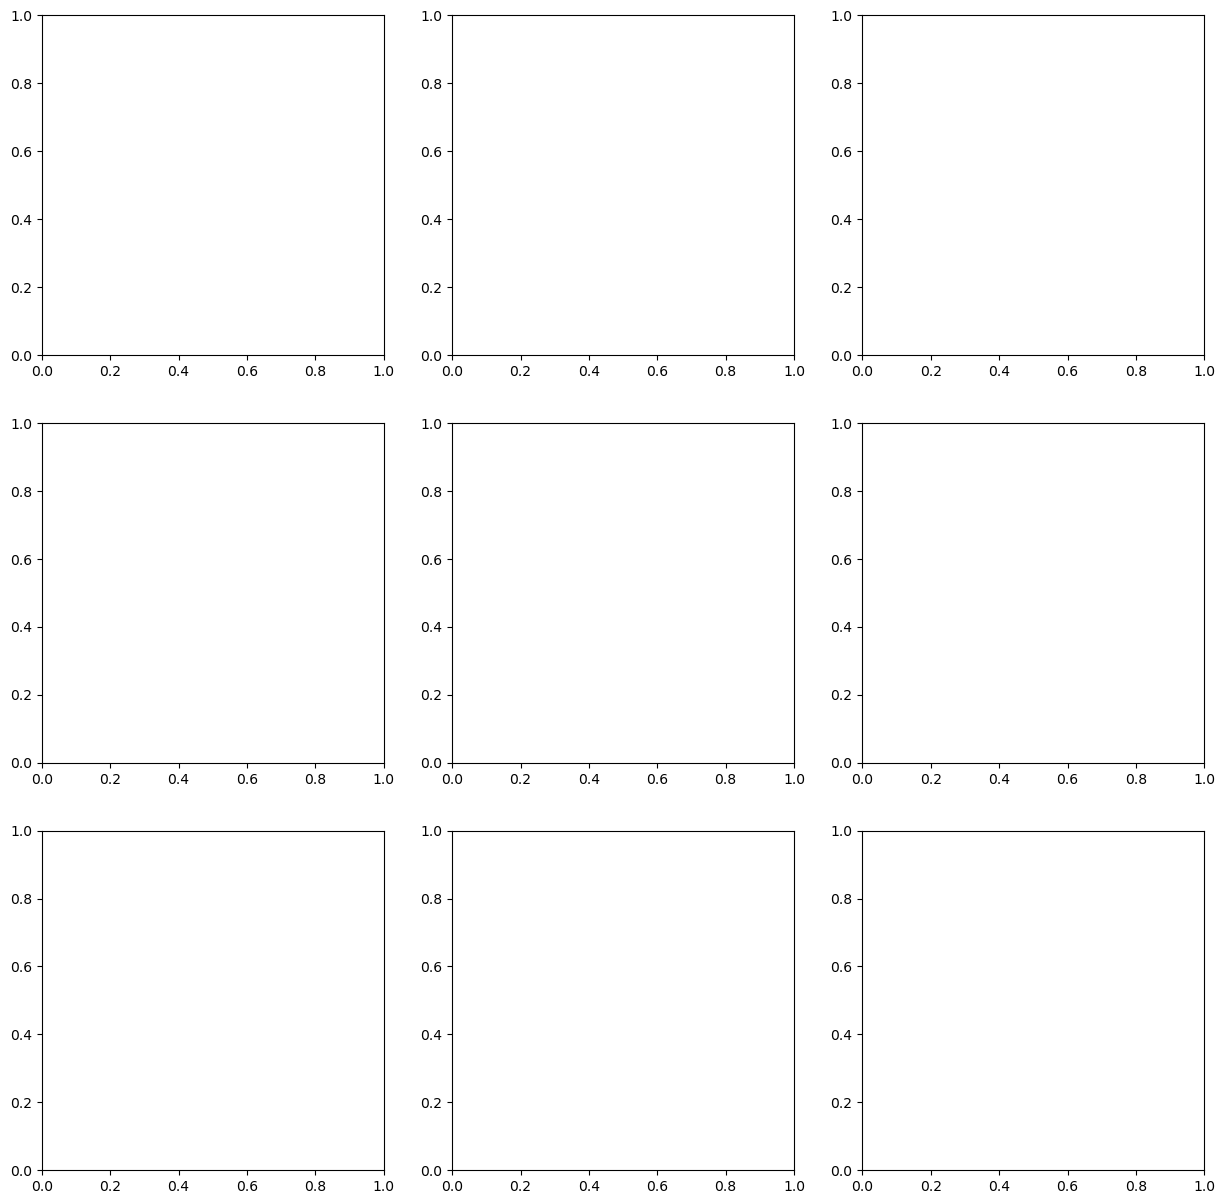

In [ ]:
import matplotlib.pyplot as plt

# Seleccionar columnas a partir de 'GDS'
cols_to_plot = df.loc[:, 'GDS':].columns
num_cols = len(cols_to_plot)

n_cols = 3
n_rows = 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))

# Flatten axes to iterate easily if it is a 2D array
axes_flat = axes.flatten()

for i, col in enumerate(cols_to_plot):
    df[col].value_counts().plot(kind='bar', ax=axes_flat[i])
    axes_flat[i].set_title(f'Value Counts: {col}')
    axes_flat[i].set_xlabel('Categories')
    axes_flat[i].set_ylabel('Frequency')

# Hide unused subplots if num_cols < total slots in the grid
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()